In [3]:
import numpy as np 
import matplotlib.pyplot as plt 
import sys, glob
import os
import lenstronomy 
import scipy.signal as scp 

from numpy.fft import fft2, ifft2, fftfreq
from scipy.special import hyp2f1
from lenstronomy.LensModel.lens_model import LensModel 
from lenstronomy.Util import util, image_util, kernel_util, param_util

In [8]:
def potential_from_kappa(kappa_grid, grid_spacing): 
    numpix = len(kappa_grid) * 2
    if numpix % 2 == 0: 
        numpix += 1
    kernel = potential_kernel(numpix, grid_spacing)
    f_ = scp.fftconvolve(kappa_grid, kernel, mode='same') / np.pi * grid_spacing ** 2.
    return f_ 

def potential_kernel(num_pix, delta_pix):
    x_shift, y_shift = util.make_grid(numPix=num_pix, deltapix = delta_pix)
    r2 = x_shift ** 2. + y_shift ** 2.
    r2max = np.max(r2)
    r2[r2 < (delta_pix / 2) ** 2] = (delta_pix / 2) ** 2
    lnr = np.log(r2 / r2max)  / 2.0
    kernel = util.array2image(lnr)
    return kernel

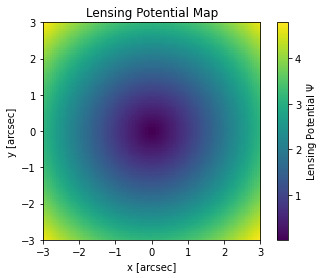

In [6]:
lensmodel_params = [{'theta_E':1., 'gamma':1.8, 'e1':0.01, 'e2':0.03, 'center_x':0.0, 'center_y':0.0}]
lensmodel_list = ['EPL']
x_grid, y_grid = np.meshgrid(np.linspace(-3, 3, 100), np.linspace(-3, 3, 100))

lensmodel = LensModel(lens_model_list=lensmodel_list)
kappa_map_lenstronomy = lensmodel.kappa(x_grid, y_grid, lensmodel_params)
potential_lenstronomy = lensmodel.potential(x_grid, y_grid, lensmodel_params)
plt.imshow(potential_lenstronomy, extent = (-3, 3, -3, 3), cmap = 'viridis', origin = 'lower', interpolation='nearest')
plt.colorbar(label=r"Lensing Potential $\Psi$")
plt.xlabel('x [arcsec]')
plt.ylabel('y [arcsec]')
plt.title('Lensing Potential Map')
plt.show()

In [6]:
def potential_from_kappa(kappa_map, pix_scale): 
    n = kappa_map.shape[0]
    L = n * pix_scale
    dk = 1.0 / L
    print(L)
    kx = fftfreq(n, d=pix_scale)
    ky = fftfreq(n, d=pix_scale)
    kx, ky = np.meshgrid(kx, ky)
    
    k2 = kx ** 2  + ky ** 2
    k2[0,0] = 1.0
    print(k2)
    kappa_ft = fft2(kappa_map)
    psi_ft = -2 * kappa_ft  / (4 * np.pi ** 2. * k2)
    potential_map = np.real(ifft2(psi_ft))
    
    return potential_map

pot1 = potential_from_kappa(kappa_map_lenstronomy, 0.05)
print(pot1, potential_lenstronomy)


5.0
[[1.   0.04 0.16 ... 0.36 0.16 0.04]
 [0.04 0.08 0.2  ... 0.4  0.2  0.08]
 [0.16 0.2  0.32 ... 0.52 0.32 0.2 ]
 ...
 [0.36 0.4  0.52 ... 0.72 0.52 0.4 ]
 [0.16 0.2  0.32 ... 0.52 0.32 0.2 ]
 [0.04 0.08 0.2  ... 0.4  0.2  0.08]]
[[0.29176143 0.29128536 0.29037428 ... 0.29050899 0.29137596 0.2917969 ]
 [0.29127115 0.29074423 0.28978824 ... 0.29016261 0.29098929 0.29136177]
 [0.29033194 0.28976008 0.28876049 ... 0.28934252 0.29013455 0.29046672]
 ...
 [0.29046672 0.29013455 0.28934252 ... 0.28876049 0.28976008 0.29033194]
 [0.29136177 0.29098929 0.29016261 ... 0.28978824 0.29074423 0.29127115]
 [0.2917969  0.29137596 0.29050899 ... 0.29037428 0.29128536 0.29176143]] [[4.65537517 4.59973878 4.54482643 ... 4.66908369 4.72560429 4.78281485]
 [4.59886947 4.54274682 4.48734445 ... 4.61013286 4.66710333 4.72476029]
 [4.54309161 4.48647872 4.43058199 ... 4.55186802 4.60929232 4.66739934]
 ...
 [4.66739934 4.60929232 4.55186802 ... 4.43058199 4.48647872 4.54309161]
 [4.72476029 4.66710333 4.6

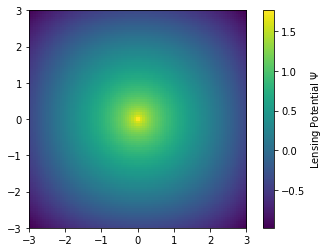

In [35]:
plt.imshow(pot1 - np.median(pot1) - (potential_lenstronomy - np.median(potential_lenstronomy)), extent=(-3, 3,-3,3),cmap='viridis', interpolation='nearest',origin='lower')
plt.colorbar(label=r'Lensing Potential $\Psi$')

## Writing out the parameters -> potential conversion

In [2]:
def param_conv(theta_E, gamma, e1, e2): 
    t = gamma -1
    phi_G, q = param_util.ellipticity2phi_q(e1, e2)
    b = theta_E * np.sqrt(q)
    return b, t, q, phi_G

def potential_from_deflections(x,y,b,t,q,phi_G,center_x=0, center_y=0): 
    x_ = x - center_x
    y_ = y - center_y
    
    x__, y__ = util.rotate(x_,y_,phi_G)
    alpha_star_x, alpha_star_y = derivatives(x__,y__,b,t,q)
    alpha_x, alpha_y = util.rotate(alpha_star_x, alpha_star_y, -phi_G)
    
    pot = (x * alpha_x + y * alpha_y) / (2 - t)
    return pot

def derivatives(x,y,b,t,q):
    Z = np.empty(np.shape(x), dtype=complex)
    Z.real = q * x
    Z.imag = y
    R = np.abs(Z)
    R = np.maximum(R, 0.000000001)
    
    R_omega = Z * hyp2f1(1, t/2., 2-t/2., -(1-q) / (1+q) * (Z / Z.conj()))
    
    alpha = 2 / (1+q) * (b/R) ** t * R_omega 
    
    alpha.real = np.nan_to_num(alpha.real, posinf=10**10, neginf=(-10 ** 10))
    alpha.imag = np.nan_to_num(alpha.imag, posinf=10**10, neginf=(-10 ** 10))

    return alpha.real, alpha.imag




In [23]:
def hessian(x,y,b,t,q,phi_G): 
    
    R = np.hypot(q * x, y)
    R = np.maximum(R, 0.00000001)
    r = np.hypot(x, y)
    
    
    cos, sin = x/r, y/r
    cos2, sin2 = cos * cos * 2 - 1, cos * sin * 2
    kappa = (2 - t) / 2. * (b / R) ** t
    kappa = np.nan_to_num(kappa, posinf=10**10, neginf=-10**10)
    alpha_x, alpha_y = derivatives(x,y,b,t,q)
    
    gamma_1 = (1 - t) * (alpha_x * cos - alpha_y * sin) / r - kappa * cos2
    gamma_2 = (1 - t) * (alpha_y * cos + alpha_x * sin) / r - kappa * sin2
    
    gamma_1 = np.nan_to_num(gamma_1, posinf=10**10, neginf=-10**10)
    gamma_2 = np.nan_to_num(gamma_2, posinf=10**10, neginf=-10**10)
    
    f_xx = kappa+gamma_1
    f_yy = kappa - gamma_1
    f_xy = gamma_2
    return f_xx, f_xy, f_xy, f_yy

def kappa_fromdef(x, y, theta_E, gamma, e1, e2, center_x = 0, center_y = 0): 
    b,t,q,phi_G = param_conv(theta_E, gamma, e1, e2)
      
    
    x_ = x-center_x
    y_ = y-center_y
    x__, y__ = util.rotate(x_, y_, phi_G)
    
    
    f__xx, f__xy, f__yx, f__yy = hessian(x, y, b,t,q,phi_G)
    kappa_ = 1. / 2.0 * (f__xx + f__yy)
    gamma1_ = 1. / 2.0 * (f__xx - f__yy)
    gamma2_ = f__xy
    
    gamma1 = np.cos(2 * phi_G) * gamma1_ -  np.sin(2 * phi_G) * gamma2_
    gamma2 = np.sin(2 * phi_G) * gamma1_ + np.cos(2 * phi_G) * gamma2_
    
    f_xx = kappa_ + gamma1
    f_yy = kappa_ - gamma1
    f_xy = gamma2
    
    kappa = 1. / 2.0 * (f_xx + f_yy)

    return kappa

0.968861775454357 0.8 0.9386931399365689 0.6245228861991272


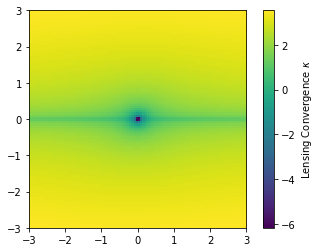

In [27]:
theta_E = 1.
gamma = 1.8
e1 = 0.01
e2 = 0.03
x_grid, y_grid = np.meshgrid(np.linspace(-3, 3, 100), np.linspace(-3, 3, 100))

b,t,q,phi_G = param_conv(theta_E, gamma, e1, e2)
print(b,t,q,phi_G)
kappa = kappa_fromdef(x_grid, y_grid, b,t,q,phi_G)
#potential_from_deflections(x_grid, y_grid, b,t,q,phi_G)
plt.imshow(kappa - kappa_map_lenstronomy, extent=(-3,3,-3,3), origin='lower',interpolation='nearest', cmap='viridis')
plt.colorbar(label='Lensing Convergence $\kappa$')

In [46]:
hyp2f1?

## <span style="color:brown"> Potential inferred from our code versus lenstronomy </span>

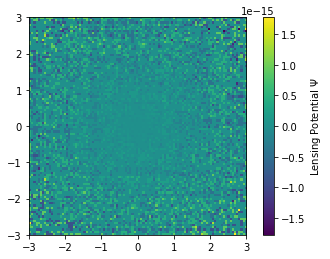

In [18]:
theta_E = 1.
gamma = 1.8
e1 = 0.01
e2 = 0.03
x_grid, y_grid = np.meshgrid(np.linspace(-3, 3, 100), np.linspace(-3, 3, 100))

b,t,q,phi_G = param_conv(theta_E, gamma, e1, e2)
psi = potential_from_deflections(x_grid, y_grid, b,t,q,phi_G)
plt.imshow(psi - potential_lenstronomy, extent=(-3,3,-3,3), origin='lower',interpolation='nearest', cmap='viridis')
plt.colorbar(label='Lensing Potential $\Psi$')

## <span style="color:purple">Deflections from lenstronomy and FFT </span>

In [4]:
def deflection_from_kappa(kappa, dx=0.05): 
    """
    inputs: kappa map, pixel size (assuming a square pixel)
    """
    ny, nx = kappa.shape 
    kx = np.fft.fftfreq(nx, d=dx) * 2 * np.pi
    ky = np.fft.fftfreq(ny, d=dx) * 2 * np.pi
    
    kx, ky = np.meshgrid(kx, ky)
    k2 = kx ** 2. + ky ** 2.
    
    kappa_ft = np.fft.fft2(kappa)
    with np.errstate(divide='ignore', invalid='ignore'):
        alpha_x_fft = -2j * kx / k2 * kappa_ft
        alpha_y_fft = -2j * ky / k2 * kappa_ft
        alpha_x_fft[k2 == 0] = 0
        alpha_y_fft[k2 == 0] = 0
    alpha_x = np.fft.ifft2(alpha_x_fft).real
    alpha_y = np.fft.ifft2(alpha_y_fft).real
    return alpha_x, alpha_y

lensmodel_interpol = LensModel(lens_model_list=['INTERPOL'])
lens_params_interpol = lensmodel_interpol

## <span style="color:purple"> Hessian from lenstronomy and FFT </span>

In [24]:
def hessian_from_kappa(kappa, dx=0.05): 
    """
    Input: kappa, 
    Optional Input: pixel size (square shape)
    Returns: f_xx, f_xy, f_xy, f_yy
    """
    nx, ny = kappa.shape
    kx = np.fft.fftfreq(nx, d=dx) * 2 * np.pi
    ky = np.fft.fftfreq(ny, d=dx) * 2 * np.pi
    
    kx, ky = np.meshgrid(kx, ky)
    
    k2 = kx ** 2. + ky ** 2.
    
    kappa_ft = np.fft.fft2(kappa)
    with np.errstate(divide='ignore', invalid='ignore'):
        psi_xx = 2 * (kx * kx / k2) * kappa_ft
        psi_xy = 2 * (kx * ky / k2) * kappa_ft
        psi_yy = 2 * (ky * ky / k2) * kappa_ft
        psi_xx[k2 == 0] = 0
        psi_xy[k2 == 0] = 0
        psi_yy[k2 == 0] = 0
        
    f_xx = np.fft.ifft2(psi_xx).real
    f_xy = np.fft.ifft2(psi_xy).real
    f_yy = np.fft.ifft2(psi_yy).real
    return f_xx, f_xy, f_xy, f_yy

In [25]:
hessian_from_kappa(kappa_map_lenstronomy, dx=0.05)

(array([[-0.17517516, -0.17443024, -0.17106209, ..., -0.1734806 ,
         -0.17801679, -0.18424576],
        [-0.17284102, -0.17204815, -0.16946125, ..., -0.17590777,
         -0.18127982, -0.18755018],
        [-0.17311284, -0.17144018, -0.1688025 , ..., -0.1782013 ,
         -0.18361755, -0.18913761],
        ...,
        [-0.18913761, -0.18361755, -0.1782013 , ..., -0.1688025 ,
         -0.17144018, -0.17311284],
        [-0.18755018, -0.18127982, -0.17590777, ..., -0.16946125,
         -0.17204815, -0.17284102],
        [-0.18424576, -0.17801679, -0.1734806 , ..., -0.17106209,
         -0.17443024, -0.17517516]]),
 array([[-0.02548877, -0.01889547, -0.01724152, ..., -0.01619424,
         -0.01807181, -0.02533888],
        [-0.0189086 , -0.01852778, -0.01709488, ..., -0.01363067,
         -0.01653654, -0.01808481],
        [-0.01726562, -0.01710588, -0.0170519 , ..., -0.01170863,
         -0.01364073, -0.0162178 ],
        ...,
        [-0.0162178 , -0.01364073, -0.01170863, ..., -

In [21]:
f_xx, f_xy, f_yx, f_yy = lensmodel.hessian(x_grid, y_grid, lensmodel_params)

f_x, f_y = lensmodel.alpha(x_grid, y_grid, lensmodel_params)
f = lensmodel.potential(x_grid, y_grid, lensmodel_params)
lens_param = [{'f_':f, 'f_x':f_x, 'f_y':f_y, 'f_xx':f_xx, 'f_xy':f_xy, 
               'f_yy':f_yy}]
lensmodel_interpol.kappa(x_grid, y_grid, lens_param)


ValueError: too many values to unpack (expected 2)